In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

In [14]:
data = pd.read_csv("../data/visitor_prediction_features_snapshot.csv")
data["month"] = pd.to_datetime(data["month"])

data = data.sort_values(["country", "month"]).reset_index(drop=True)

print(data.shape)
data.head()

(9104, 10)


,country,month,visitor_arrivals,gdp,exchange_rate,public_holiday_count,aircraft_passengers,traffic_volume,hotel_rate,hotel_occupancy
0,Australia,1978-01-01,20379.0,135608.0,NaN,2,NaN,NaN,NaN,NaN
1,Australia,1978-02-01,18852.0,135608.0,NaN,0,NaN,NaN,NaN,NaN
2,Australia,1978-03-01,20819.0,135608.0,NaN,9,NaN,NaN,NaN,NaN
3,Australia,1978-04-01,18697.0,135608.0,NaN,1,NaN,NaN,NaN,NaN
4,Australia,1978-05-01,19797.0,135608.0,NaN,3,NaN,NaN,NaN,NaN


In [15]:
data["log_arrivals"] = np.log1p(data["visitor_arrivals"])
features = [
    "aircraft_passengers",
    "traffic_volume",
    "hotel_rate",
    "hotel_occupancy"
]

target = "log_arrivals"

df = data[["country", "month"] + features + [target]].copy()

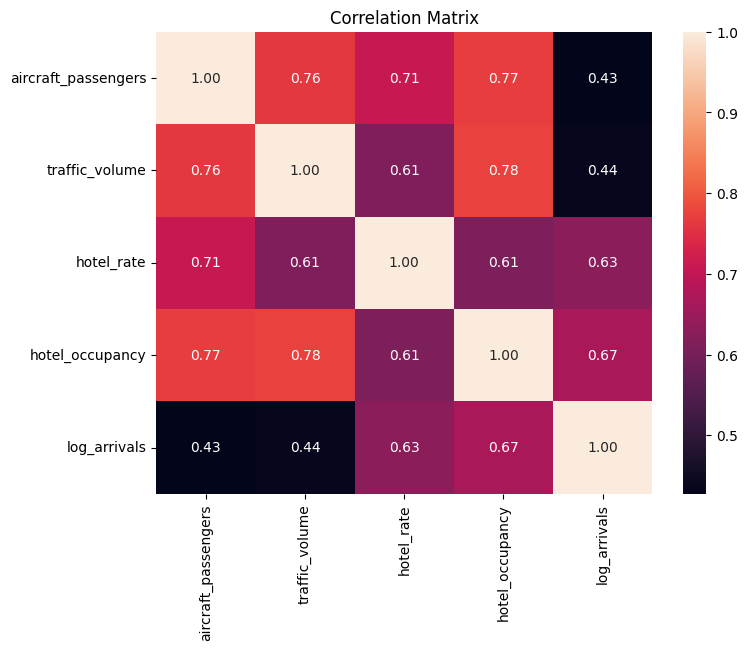

In [16]:
corr = df[features + [target]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [17]:
country_corrs = []

for country, g in df.groupby("country"):
    for col in features:
        temp = g[[col, target]].dropna()
        
        if len(temp) < 10:
            continue
        
        corr = temp[col].corr(temp[target])
        
        country_corrs.append({
            "country": country,
            "feature": col,
            "correlation": corr
        })

country_corr_df = pd.DataFrame(country_corrs)
country_corr_df.sort_values(["country", "correlation"], ascending=[True, False]).head(20)

,country,feature,correlation
3,Australia,hotel_occupancy,0.798753
2,Australia,hotel_rate,0.778125
0,Australia,aircraft_passengers,0.660351
1,Australia,traffic_volume,0.546948
7,Canada,hotel_occupancy,0.800066
6,Canada,hotel_rate,0.791218
4,Canada,aircraft_passengers,0.636000
5,Canada,traffic_volume,0.518602
11,France,hotel_occupancy,0.790346
10,France,hotel_rate,0.772094


In [18]:
avg_corr = (
    country_corr_df.groupby("feature")["correlation"]
    .mean()
    .sort_values(ascending=False)
)

avg_corr

feature
hotel_occupancy        0.799927
hotel_rate             0.752866
aircraft_passengers    0.577819
traffic_volume         0.534606
Name: correlation, dtype: float64

In [19]:
df["traffic_x_aircraft"] = df["traffic_volume"] * df["aircraft_passengers"]
df["hotel_x_traffic"] = df["hotel_rate"] * df["traffic_volume"]
df["hotelocc_x_aircraft"] = df["hotel_occupancy"] * df["aircraft_passengers"]

interaction_features = [
    "traffic_x_aircraft",
    "hotel_x_traffic",
    "hotelocc_x_aircraft"
]

for col in interaction_features:
    temp = df[[col, target]].dropna()
    print(col, temp[col].corr(temp[target]))

traffic_x_aircraft 0.622214092173916
hotel_x_traffic 0.6914155410322861
hotelocc_x_aircraft 0.6966049874573619


In [20]:
X = df[features].dropna()
y = df.loc[X.index, "log_arrivals"]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

model.fit(X, y)

coef = model.named_steps["lr"].coef_

coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": coef
}).sort_values("coefficient", key=abs, ascending=False)

coef_df

,feature,coefficient
0,aircraft_passengers,0.750995
2,hotel_rate,0.503421
3,hotel_occupancy,0.354476
1,traffic_volume,0.119437


In [21]:
perm = permutation_importance(
    model,
    X,
    y,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": features,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_df

,feature,importance
0,aircraft_passengers,0.277214
2,hotel_rate,0.125165
3,hotel_occupancy,0.062066
1,traffic_volume,0.007090


In [23]:
for lag in [0, 1, 2, 3]:
    df[f"aircraft_lag_{lag}"] = df.groupby("country")["aircraft_passengers"].shift(lag)

    temp = df[[f"aircraft_lag_{lag}", "log_arrivals"]].dropna()
    print(lag, temp.corr().iloc[0,1])

0 0.427495727260563
1 0.4182312648103045
2 0.39626581740600514
3 0.3625244715837943


In [24]:
country_importance = []

for country, g in df.groupby("country"):
    temp = g[["aircraft_passengers", "log_arrivals"]].dropna()
    
    if len(temp) < 20:
        continue
        
    corr = temp["aircraft_passengers"].corr(temp["log_arrivals"])
    
    country_importance.append((country, corr))

pd.DataFrame(country_importance, columns=["country", "aircraft_corr"]).sort_values("aircraft_corr", ascending=False)

,country,aircraft_corr
5,India,0.806132
2,France,0.714158
4,Hong Kong,0.670559
0,Australia,0.660351
15,United States,0.659544
3,Germany,0.646658
1,Canada,0.636000
14,United Kingdom,0.595978
12,Switzerland,0.594139
11,Sri Lanka,0.588268


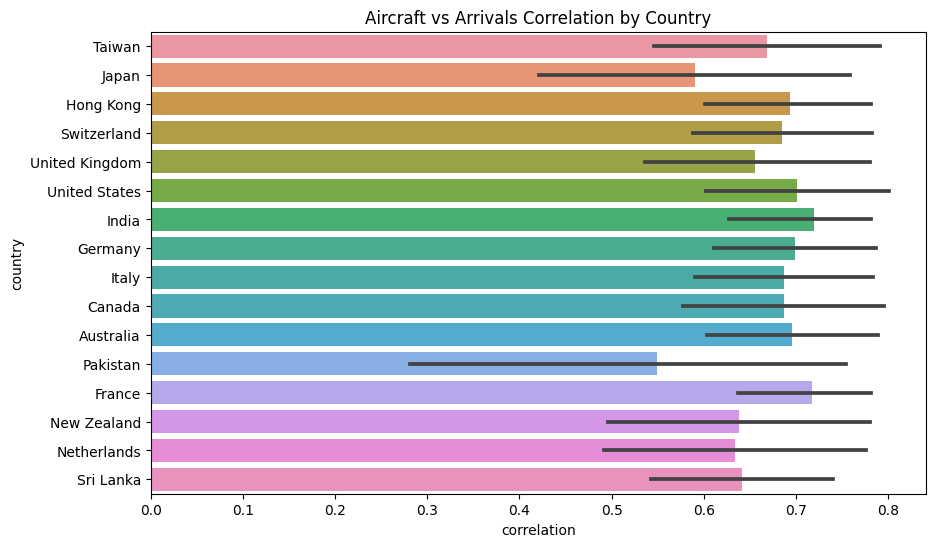

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=country_corr_df.sort_values("correlation", ascending=False),
    x="correlation",
    y="country"
)
plt.title("Aircraft vs Arrivals Correlation by Country")
plt.show()